In [25]:
import numpy as np
import lmfit

In [26]:
path = r"G:\Data\Qudi_Data\2025\01\20250121\PODMR\20250121-1320-45_A-F17-26_NbN_S1_10K_70mT_Bnv_OOC_ODMR_data_ch0_raw.dat"
data = np.loadtxt(path)
data = data[:,:]

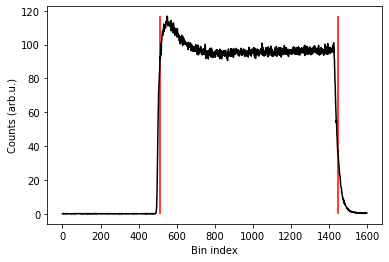

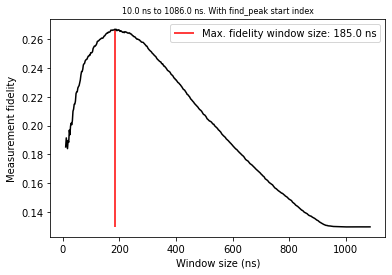

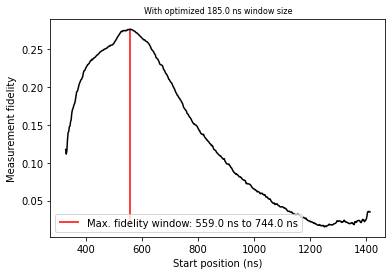

Max. fidelity window: 559.0 ns to 744.0 ns


In [5]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

y = np.mean(data, axis=0)
yfit = y
peaks,_ = find_peaks(x=yfit, height=yfit.max()*0.3)

x=np.arange(len(yfit))

plt.plot(x,yfit, 'k-')
plt.vlines([peaks[0],peaks[-1]], ymin=yfit.min(), ymax=yfit.max(),colors='r')
plt.xlabel("Bin index")
plt.ylabel("Counts (arb.u.)")
plt.show()

start, stop = peaks[0], peaks[-1]


binwidth = 1e-9
window = min(200e-9, (len(yfit)-start)*1e-9)

width = int(window/binwidth)
signal = np.sum(data[:,start:start+width], axis=1)
signal = signal/signal.max()
# s_signal = savgol_filter(signal, 10, 3) # window size 51, polynomial order 3

# plt.plot(signal,'k')
# plt.hlines([s_signal.min(), s_signal.max()], xmin=0, xmax=len(s_signal), colors='r')
# plt.xlabel("Readout Index")
# plt.ylabel("Counts (arb.u.)")
# plt.show()

########################################

win_start = 10e-9
win_stop = max(200e-9, (len(yfit)-start)*1e-9)
windows = np.linspace(win_start, win_stop, 500)


def sigma_r(signal):
    signal = signal/signal.max()
    a,b = signal[np.argmax(signal)], signal[np.argmin(signal)] 
    C = (a-b)/(a+b)
    n = (a+b)/2
    return np.sqrt(1+(1/(C**2 * n)))

def sigma_window(window, data, start):
    binwidth = 1e-9
    
    width = int(window/binwidth)
    signal = np.sum(data[:, start:start+width], axis=1)

#     s_signal = savgol_filter(signal, 10, 3) # window size 51, polynomial order 3
    return sigma_r(signal)

def fidelity(windows, data, start):
    ret = np.zeros_like(windows)
    
    for i, window in enumerate(windows):
        ret[i] = 1.0/sigma_window(window, data, start)
        
    return ret

def fidelity_for_starts(starts, data, window):
    ret = np.zeros_like(starts)
    starts = (starts/1e-9).astype(np.int32)
    
    for i, start in enumerate(starts):
        ret[i] = 1.0/sigma_window(window, data, start)
        
    return ret

fidelities = fidelity(windows, data, start)
maximum_F_ind = np.argmax(fidelities)

plt.title(f"{round(win_start*1e9,3)} ns to {round(win_stop*1e9,3)} ns. With find_peak start index", fontsize=8)
plt.plot(windows*1e9, fidelities, 'k')
plt.vlines(windows[maximum_F_ind]*1e9, ymin=fidelities.min(), ymax=fidelities.max(), colors='r', label=f"Max. fidelity window size: {round(windows[maximum_F_ind]*1e9,0)} ns")
plt.xlabel("Window size (ns)")
plt.ylabel("Measurement fidelity")
plt.legend()
plt.show()

opt_window_size = round(windows[maximum_F_ind]*1e9,0)
start_positions = np.linspace(max(0,start*binwidth-opt_window_size/1e9), len(yfit)*binwidth - opt_window_size/1e9, 500)
fidelities_s = fidelity_for_starts(start_positions, data, opt_window_size/1e9)
maximum_F_ind = np.argmax(fidelities_s)
optimal_start = round(start_positions[maximum_F_ind]*1e9,0)

plt.title(f"With optimized {opt_window_size} ns window size", fontsize=8)
plt.plot(start_positions*1e9, fidelities_s, 'k')

plt.vlines(start_positions[maximum_F_ind]*1e9, ymin=fidelities_s.min(), ymax=fidelities_s.max(), colors='r', label=f"Max. fidelity window: {optimal_start} ns to {optimal_start+opt_window_size} ns")
plt.xlabel("Start position (ns)")
plt.ylabel("Measurement fidelity")
plt.legend()
plt.show()
print(f"Max. fidelity window: {optimal_start} ns to {optimal_start+opt_window_size} ns")

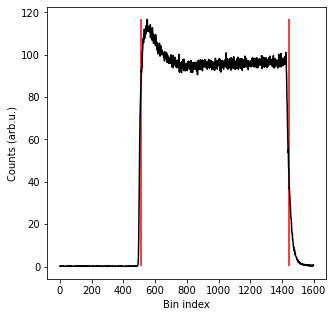

In [27]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import minimize
from scipy.optimize import brute

def sigma_r(signal):
    signal = signal/signal.max()
    a,b = signal[np.argmax(signal)], signal[np.argmin(signal)] 
    C = (a-b)/(a+b)
    n = (a+b)/2
    return np.sqrt(1+(1/(C**2 * n)))

def fidelity(start, width):
    stop = start+width
    signal = np.sum(data[:, int(start):int(stop)], axis=1)
    return 1/sigma_r(signal) #-1 to turn the maximize problem into a minimize problem

def SNR(start, width):
    stop = start+width
    signal = np.sum(data[:, int(start):int(stop)], axis=1)
    signal_max, signal_min = signal[np.argmax(signal)], signal[np.argmin(signal)] 
    return (signal_max-signal_min)/np.sqrt(signal_max+signal_min) #-1 to turn the maximize problem into a minimize problem

def fidelity_start(start, width):
    stop = start+width
    signal = np.sum(data[:, int(start):int(stop)], axis=1)
    return -1/sigma_r(signal) #-1 to turn the maximize problem into a minimize problem

def fidelity_width(width, *params):
    start = params[0]
    stop = start+width
    signal = np.sum(data[:, int(start):int(stop)], axis=1)
    return -1/sigma_r(signal) #-1 to turn the maximize problem into a minimize problem

y = np.mean(data, axis=0)
yfit = y
peaks,_ = find_peaks(x=yfit, height=yfit.max()*0.3)
peaks_ref,_ = find_peaks(x=yfit, height=yfit.max()*0.7)

x=np.arange(len(yfit))

plt.plot(x,yfit, 'k-')
plt.vlines([peaks[0],peaks[-1]], ymin=yfit.min(), ymax=yfit.max(),colors='r')
plt.xlabel("Bin index")
plt.ylabel("Counts (arb.u.)")
plt.show()

start, stop = peaks[0], peaks[-1]
optimal_ref_stop = peaks_ref[-1]
data_range = stop - start
 
# plt.title(f"{win_start} to {win_stop}. With find_peak start index", fontsize=8)
# plt.plot(windows, fidelity_windows, 'k')
# plt.vlines(windows[maximum_F_ind], ymin=fidelity_windows.min(), ymax=fidelity_windows.max(), colors='r', label=f"Max. fidelity window size: {windows[maximum_F_ind]} ")
# plt.xlabel("Window size (ns)")
# plt.ylabel("Measurement fidelity")
# plt.legend()
# plt.show()

window_width_min = 1
window_width_max = int(data_range*0.5)

window_start_min = max(start-int(data_range*0.25),0)
window_start_max = start+int(data_range/2)

window_width_arr = np.linspace(window_width_min, window_width_max,window_width_max-window_width_min+1)
window_start_arr = np.linspace(window_start_min, window_start_max,window_start_max-window_start_min+1)
fidelity_arr = np.zeros((len(window_width_arr),len(window_start_arr)))

for idx_width, window_width in enumerate(window_width_arr):
    for idx_start, window_start in enumerate(window_start_arr):
        fidelity_arr[idx_width, idx_start] = SNR(window_start, window_width)

# optimal_start = result.x[0]
# optimal_window_size = result.x[1]
# optimal_ref_window_size = optimal_window_size

# optimal_ref_start = optimal_ref_stop - optimal_ref_window_size
        
# print(f'Optimized analyses window start: {optimal_start} \n Optimized analyses window width: {optimal_window_size}')
# print(f'Optimized reference window start: {optimal_ref_start} \n Optimized reference window width: {optimal_ref_window_size}')

# plt.plot(x,yfit, 'k-')
# plt.vlines([optimal_start,optimal_start+optimal_window_size], ymin=yfit.min(), ymax=yfit.max(),colors='r')
# plt.vlines([optimal_ref_start,optimal_ref_start+optimal_ref_window_size], ymin=yfit.min(), ymax=yfit.max(),colors='g')
# plt.xlabel("Bin index")
# plt.ylabel("Counts (arb.u.)")
# plt.show()

C:\Users\yy3\anaconda3\envs\qudi\lib\site-packages\ipykernel_launcher.py:14: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  


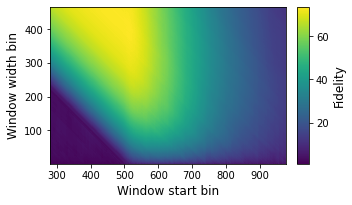

Optimal window width: 412.0
Optimal window start: 512.0
513


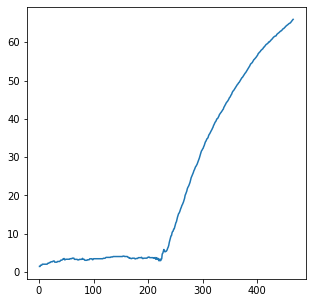

In [28]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['figure.figsize'] = (5, 5)
fontsize = 12

low_centile = 0
high_centile = 100
cmap = plt.get_cmap('viridis')

opt_width_idx, opt_start_idx = np.unravel_index(np.argmax(fidelity_arr),fidelity_arr.shape)
v_min = fidelity_arr.min()
v_max = fidelity_arr.max()

im = plt.pcolormesh(window_start_arr, window_width_arr, fidelity_arr, vmin = v_min, vmax = v_max, cmap=cmap)
plt.xlabel('Window start bin',fontsize = fontsize)
plt.ylabel('Window width bin',fontsize = fontsize)

ax = plt.gca()
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(label='Fidelity', size=fontsize)

plt.tight_layout()

plt.show()

print(f'Optimal window width: {window_width_arr[opt_width_idx]}')
print(f'Optimal window start: {window_start_arr[opt_start_idx]}')
print(start)

plt.plot(window_width_arr, fidelity_arr[:,0])
plt.show()